In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# open data downloaded via form (because API did not work)
river = xr.open_dataset(r"~/help_me/river_discharge/raw_river_discharge.nc")

In [3]:
river # data from 02.05 - 01.08.

<xarray.Dataset> Size: 57MB
Dimensions:     (valid_time: 92, latitude: 120, longitude: 320)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 736B 2024-05-02 ... 2024-08-01
  * latitude    (latitude) float64 960B 30.98 30.93 30.88 ... 25.12 25.07 25.02
  * longitude   (longitude) float64 3kB 82.03 82.08 82.12 ... 97.87 97.92 97.97
    surface     float64 8B ...
    rootZone    float64 8B ...
Data variables:
    rowe        (valid_time, latitude, longitude) float32 14MB ...
    sd          (valid_time, latitude, longitude) float32 14MB ...
    swir        (valid_time, latitude, longitude) float32 14MB ...
    dis24       (valid_time, latitude, longitude) float32 14MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-09T17:07 GRIB to CDM+CF via cfgrib-0.9.1...

In [4]:
#making dis24 nan where 0, because its describing the river discharge and 0 are no rivers (so that these values are not used later on)
river["dis24"]=river["dis24"].where(river["dis24"] != 0)

In [6]:
#masking so the dis24 only has values where actual rivers are (time dim named valid_time here)
river_mask=river["dis24"].mean(dim='valid_time')>10 # mean value >10 to ensure that there is not just water for certain timesteps

#target location for the river discharge, taken from google maps --> can be specified to fit the point we need
target_lat = 26   # change to your river location
target_lon = 90   # change to your river location

river_ts = river['dis24'].sel(latitude=target_lat, longitude=target_lon, method='nearest')

In [7]:
river_ts

<xarray.DataArray 'dis24' (valid_time: 92)> Size: 368B
array([14613.344 , 15079.5   , 17414.61  , 20086.86  , 18524.75  ,
       16615.531 , 15749.891 , 14660.109 , 13504.4375, 12588.828 ,
       12005.234 , 11576.875 , 11135.3125, 10745.125 , 10413.5625,
       10198.4375, 10353.625 , 11305.203 , 12277.031 , 12184.703 ,
       11523.344 , 10868.703 , 10375.4375, 10181.766 , 10349.719 ,
       10416.406 , 11985.656 , 17231.625 , 26247.14  , 35686.016 ,
       35882.64  , 32020.094 , 30087.422 , 29842.188 , 29465.484 ,
       28394.828 , 25685.469 , 23430.797 , 22039.719 , 21694.375 ,
       22093.578 , 22780.688 , 23643.812 , 25054.75  , 29241.453 ,
       34013.75  , 37023.688 , 41475.58  , 47937.297 , 53402.844 ,
       54493.14  , 48452.562 , 41897.547 , 37510.594 , 35697.5   ,
       37318.28  , 40871.438 , 42052.92  , 44188.938 , 56818.562 ,
       73660.97  , 81362.234 , 77248.69  , 65873.016 , 59154.08  ,
       60508.5   , 63080.64  , 59466.797 , 54104.438 , 50951.562 ,
       49737.78  , 50904.14  , 52110.875 , 51717.547 , 50222.812 ,
       49659.125 , 49159.14  , 47585.703 , 45013.703 , 42543.594 ,
       41022.406 , 41168.03  , 43372.812 , 44740.516 , 43163.203 ,
       40484.766 , 38546.203 , 37477.72  , 36448.61  , 35889.047 ,
       35855.25  , 34876.297 ], dtype=float32)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 736B 2024-05-02 ... 2024-08-01
    surface     float64 8B ...
    latitude    float64 8B 26.02
    longitude   float64 8B 90.02
    rootZone    float64 8B ...
Attributes: (12/32)
    GRIB_paramId:                             240024
    GRIB_dataType:                            sfo
    GRIB_numberOfPoints:                      38400
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avg
    ...                                       ...
    GRIB_name:                                Mean discharge in the last 24 h...
    GRIB_shortName:                           dis24
    GRIB_units:                               m**3 s**-1
    long_name:                                Mean discharge in the last 24 h...
    units:                                    m**3 s**-1
    standard_name:                            unknown

In [8]:
max_dis = river_ts.max()
max_dis

<xarray.DataArray 'dis24' ()> Size: 8B
array(81362.234375)
Coordinates:
    surface    float64 8B ...
    latitude   float64 8B 26.02
    longitude  float64 8B 90.02
    rootZone   float64 8B ...
Attributes: (12/32)
    GRIB_paramId:                             240024
    GRIB_dataType:                            sfo
    GRIB_numberOfPoints:                      38400
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avg
    ...                                       ...
    GRIB_name:                                Mean discharge in the last 24 h...
    GRIB_shortName:                           dis24
    GRIB_units:                               m**3 s**-1
    long_name:                                Mean discharge in the last 24 h...
    units:                                    m**3 s**-1
    standard_name:                            unknown

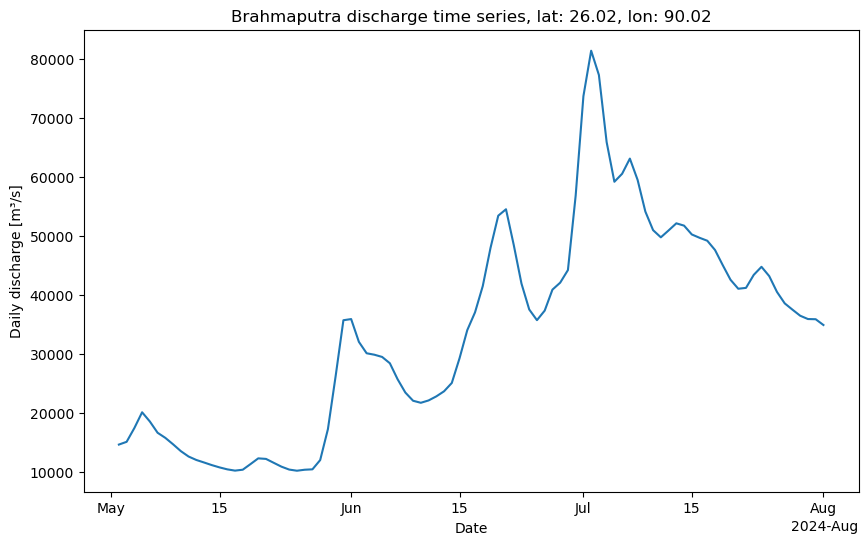

In [9]:
# graph does not show any NaNs for the selected point (+ look at peak value
plt.figure(figsize=(10, 6))
river_ts.plot()
plt.ylabel("Daily discharge [m³/s]")
plt.title("Brahmaputra discharge time series, lat: 26.02, lon: 90.02")
plt.xlabel("Date")
plt.show()